# k-means vs k-means++ on the Norm25 dataset

Norm25 is the synthetic benchmark from Arthur and Vassilvitskii's 2007 k-means++ paper. The setup is designed so vanilla k-means does badly: 25 true centres are drawn uniformly from a 15-dimensional cube of side 500, and around each centre we scatter Gaussian points with std = 1. Within-cluster scatter is tiny compared to the gaps between centres, so the optimal clustering is essentially "one centre per blob". An algorithm that misses a blob and merges two pays a large inertia cost.

Libraries: numpy, matplotlib.

## Step 1: imports and config

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Norm25 settings (Arthur & Vassilvitskii, 2007)
MASTER_SEED = 42        # for reproducibility
N_TRIALS = 50
K = 25                  # number of true clusters
N_FEATURES = 15
HYPERCUBE_SIDE = 500    # centres drawn uniformly from [0, 500]^15
STD = 1.0               # std of each Gaussian blob
N_SAMPLES = 10000

## Step 2: build the Norm25 dataset

1. Pick 25 centres uniformly at random in [0, 500]^15.
2. Around each centre, draw 400 points from an isotropic Gaussian with std = 1.

The result: 25 tight blobs scattered across a huge 15-D box, with the distance between centres orders of magnitude larger than the within-cluster spread.

In [2]:
def make_blobs(n_samples, n_centers, n_features, std, side_length, rng):
    n_per = n_samples // n_centers
    centers = rng.uniform(0, side_length, size=(n_centers, n_features))

    X_parts, y_parts = [], []
    for i, center in enumerate(centers):
        points = rng.normal(loc=center, scale=std, size=(n_per, n_features))
        X_parts.append(points)
        y_parts.append(np.full(n_per, i, dtype=int))

    X = np.vstack(X_parts)
    labels = np.concatenate(y_parts)
    return X, labels, centers


# build the Norm25 dataset
rng = np.random.default_rng(MASTER_SEED)
X, y_true, true_centers = make_blobs(
    N_SAMPLES, K, N_FEATURES, STD, HYPERCUBE_SIDE, rng
)
print(f"X shape: {X.shape}")

X shape: (10000, 15)


## Step 3: the two algorithms

Both algorithms run the same Lloyd iteration after seeding:
1. Assign each point to its nearest centre.
2. Move each centre to the mean of its assigned points.
3. Repeat until the centres stop moving.

The only difference is how the initial centres are chosen:
- k-means: pick k data points uniformly at random.
- k-means++: pick the first centre uniformly, then each next centre with probability proportional to its squared distance from the nearest already-chosen centre.

In [3]:
def sq_dists(X, C):
    # squared distances from each row of X to each row of C, shape (n, k)
    diff = X[:, None, :] - C[None, :, :]
    return (diff ** 2).sum(axis=-1)


def lloyd(X, centers, max_iter=300, tol=1e-4):
    k = len(centers)
    for _ in range(max_iter):
        labels = np.argmin(sq_dists(X, centers), axis=1)
        new_centers = np.zeros_like(centers)
        for j in range(k):
            mask = labels == j
            if mask.any():
                new_centers[j] = X[mask].mean(axis=0)
            else:
                new_centers[j] = centers[j]
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        if shift < tol:
            break

    labels = np.argmin(sq_dists(X, centers), axis=1)
    D2 = sq_dists(X, centers)
    inertia = float(D2[np.arange(len(X)), labels].sum())
    return labels, inertia


def kmeans(X, k, rng):
    # uniform random seeding
    idx = rng.choice(len(X), size=k, replace=False)
    return lloyd(X, X[idx].copy())


def kmeans_pp(X, k, rng):
    # D^2 weighted seeding
    n = len(X)
    first = int(rng.integers(0, n))
    centers = [X[first].copy()]
    d2 = sq_dists(X, np.array([centers[0]])).ravel()

    for _ in range(k - 1):
        s = d2.sum()
        if s == 0:
            idx = int(rng.integers(0, n))
        else:
            idx = int(rng.choice(n, p=d2 / s))
        centers.append(X[idx].copy())
        d2 = np.minimum(d2, sq_dists(X, np.array([centers[-1]])).ravel())

    return lloyd(X, np.array(centers))


# quick sanity check
rng_test = np.random.default_rng(0)
_, phi_km = kmeans(X, K, rng_test)
_, phi_pp = kmeans_pp(X, K, rng_test)
print(f"k-means   inertia: {phi_km:,.0f}")
print(f"k-means++ inertia: {phi_pp:,.0f}")

k-means   inertia: 350,036,630
k-means++ inertia: 150,866


## Step 4: run 50 trials each

Each algorithm runs 50 times with different seeds. We collect every inertia value and use the two arrays for the rest of the analysis.

In [4]:
def run_trials(X, k, n_trials=N_TRIALS, master_seed=MASTER_SEED):
    km_inertias = np.zeros(n_trials)
    pp_inertias = np.zeros(n_trials)

    for t in range(n_trials):
        rng = np.random.default_rng(master_seed + t)
        _, km_inertias[t] = kmeans(X, k, rng)

        rng = np.random.default_rng(master_seed + t)  # same seed, fair comparison
        _, pp_inertias[t] = kmeans_pp(X, k, rng)

    return km_inertias, pp_inertias


km_inertias, pp_inertias = run_trials(X, K)

print(f"{'Metric':<10} {'k-means':>16} {'k-means++':>16}")
print("-" * 44)
for label, fn in [("Mean", np.mean), ("Std", np.std), ("Min", np.min),
                  ("Median", np.median), ("Max", np.max)]:
    print(f"{label:<10} {fn(km_inertias):>16,.0f} {fn(pp_inertias):>16,.0f}")

improvement = 100 * (1 - pp_inertias.mean() / km_inertias.mean())
print(f"\nMean inertia improvement of k-means++ over k-means: {improvement:+.1f}%")
print("\nNote: on Norm25, k-means++ converges to the same near-optimal solution every run, so its std across trials is essentially 0.")

Metric              k-means        k-means++
--------------------------------------------
Mean            368,624,442          150,866
Std             101,580,610                0
Min             108,331,674          150,866
Median          366,005,648          150,866
Max             558,467,396          150,866

Mean inertia improvement of k-means++ over k-means: +100.0%

Note: on Norm25, k-means++ converges to the same near-optimal solution every run, so its std across trials is essentially 0.


## Step 5: comparison plots

Which algorithm finds a lower-inertia clustering?

- histogram of inertias across the 50 trials
- per-trial scatter
- box plot side by side
- bar chart of the means

Inertias differ by orders of magnitude between the two on Norm25, so the value axis is on a log scale.

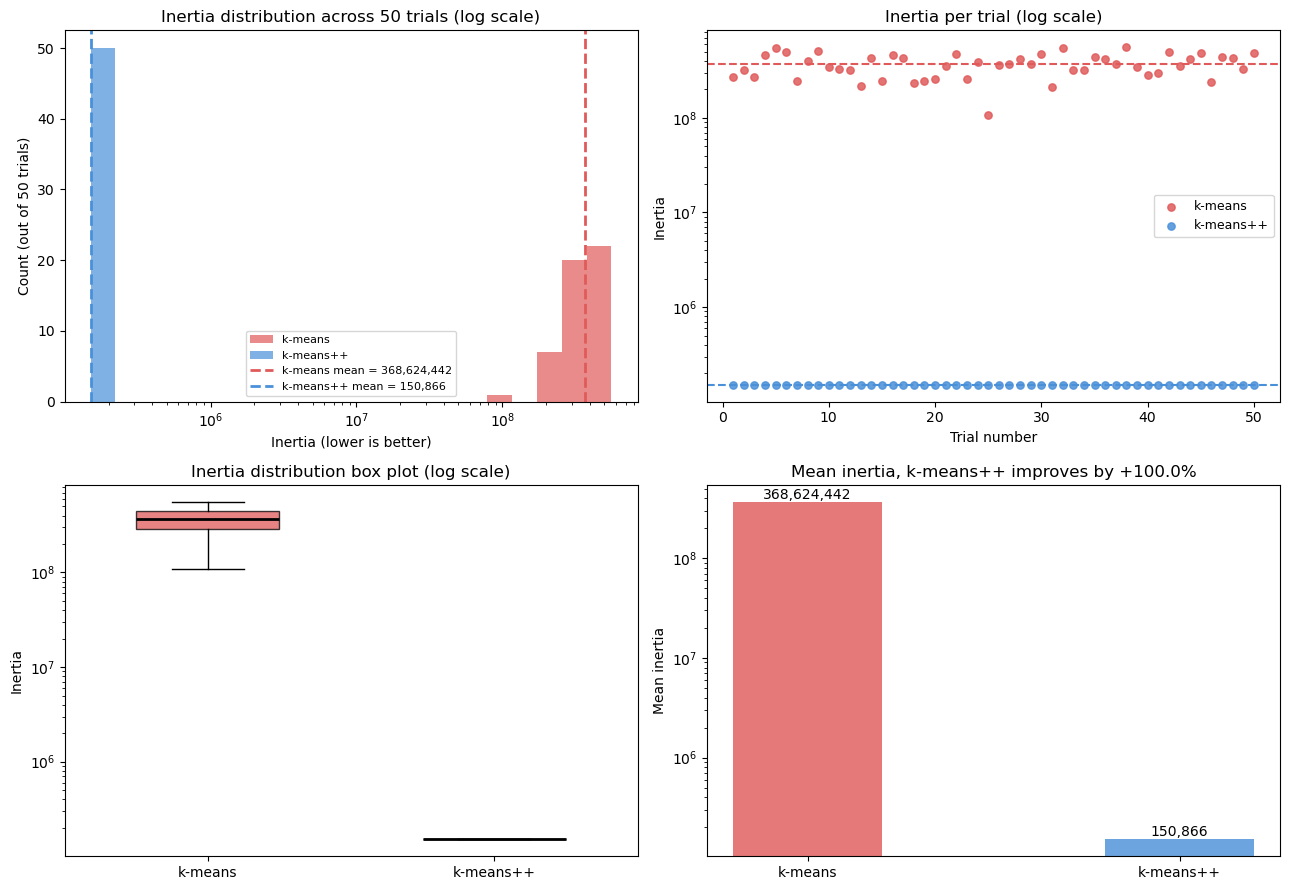

In [5]:
RED = "#E05A5A"
BLUE = "#4A90D9"

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# panel 1: histograms
ax = axes[0, 0]
lo = min(km_inertias.min(), pp_inertias.min())
hi = max(km_inertias.max(), pp_inertias.max())
bins = np.logspace(np.log10(lo), np.log10(hi), 22)
ax.hist(km_inertias, bins=bins, alpha=0.7, color=RED, label="k-means")
ax.hist(pp_inertias, bins=bins, alpha=0.7, color=BLUE, label="k-means++")
ax.axvline(km_inertias.mean(), color=RED, linestyle="--", linewidth=2,
           label=f"k-means mean = {km_inertias.mean():,.0f}")
ax.axvline(pp_inertias.mean(), color=BLUE, linestyle="--", linewidth=2,
           label=f"k-means++ mean = {pp_inertias.mean():,.0f}")
ax.set_xscale("log")
ax.set_title("Inertia distribution across 50 trials (log scale)")
ax.set_xlabel("Inertia (lower is better)")
ax.set_ylabel(f"Count (out of {N_TRIALS} trials)")
ax.legend(fontsize=8)

# panel 2: per-trial scatter
ax = axes[0, 1]
t = np.arange(1, N_TRIALS + 1)
ax.scatter(t, km_inertias, color=RED, s=28, alpha=0.85, label="k-means")
ax.scatter(t, pp_inertias, color=BLUE, s=28, alpha=0.85, label="k-means++")
ax.axhline(km_inertias.mean(), color=RED, linestyle="--", linewidth=1.5)
ax.axhline(pp_inertias.mean(), color=BLUE, linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_title("Inertia per trial (log scale)")
ax.set_xlabel("Trial number")
ax.set_ylabel("Inertia")
ax.legend(fontsize=9)

# panel 3: box plots
ax = axes[1, 0]
bp = ax.boxplot([km_inertias, pp_inertias],
                labels=["k-means", "k-means++"],
                patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], [RED, BLUE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_yscale("log")
ax.set_title("Inertia distribution box plot (log scale)")
ax.set_ylabel("Inertia")

# panel 4: mean inertia bar
ax = axes[1, 1]
bars = ax.bar(["k-means", "k-means++"],
              [km_inertias.mean(), pp_inertias.mean()],
              color=[RED, BLUE], alpha=0.82, width=0.4)
for bar, val in zip(bars, [km_inertias.mean(), pp_inertias.mean()]):
    ax.text(bar.get_x() + bar.get_width()/2, val,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=10)
ax.set_yscale("log")
ax.set_title(f"Mean inertia, k-means++ improves by {improvement:+.1f}%")
ax.set_ylabel("Mean inertia")

plt.tight_layout()
plt.show()

## Step 6: stability plots

Which algorithm is more consistent across runs?

- coefficient of variation: std / mean, lower means more stable
- ECDF: a curve further left means low inertia is reached more often
- range between best and worst trial
- running mean: how fast the average settles as trials accumulate

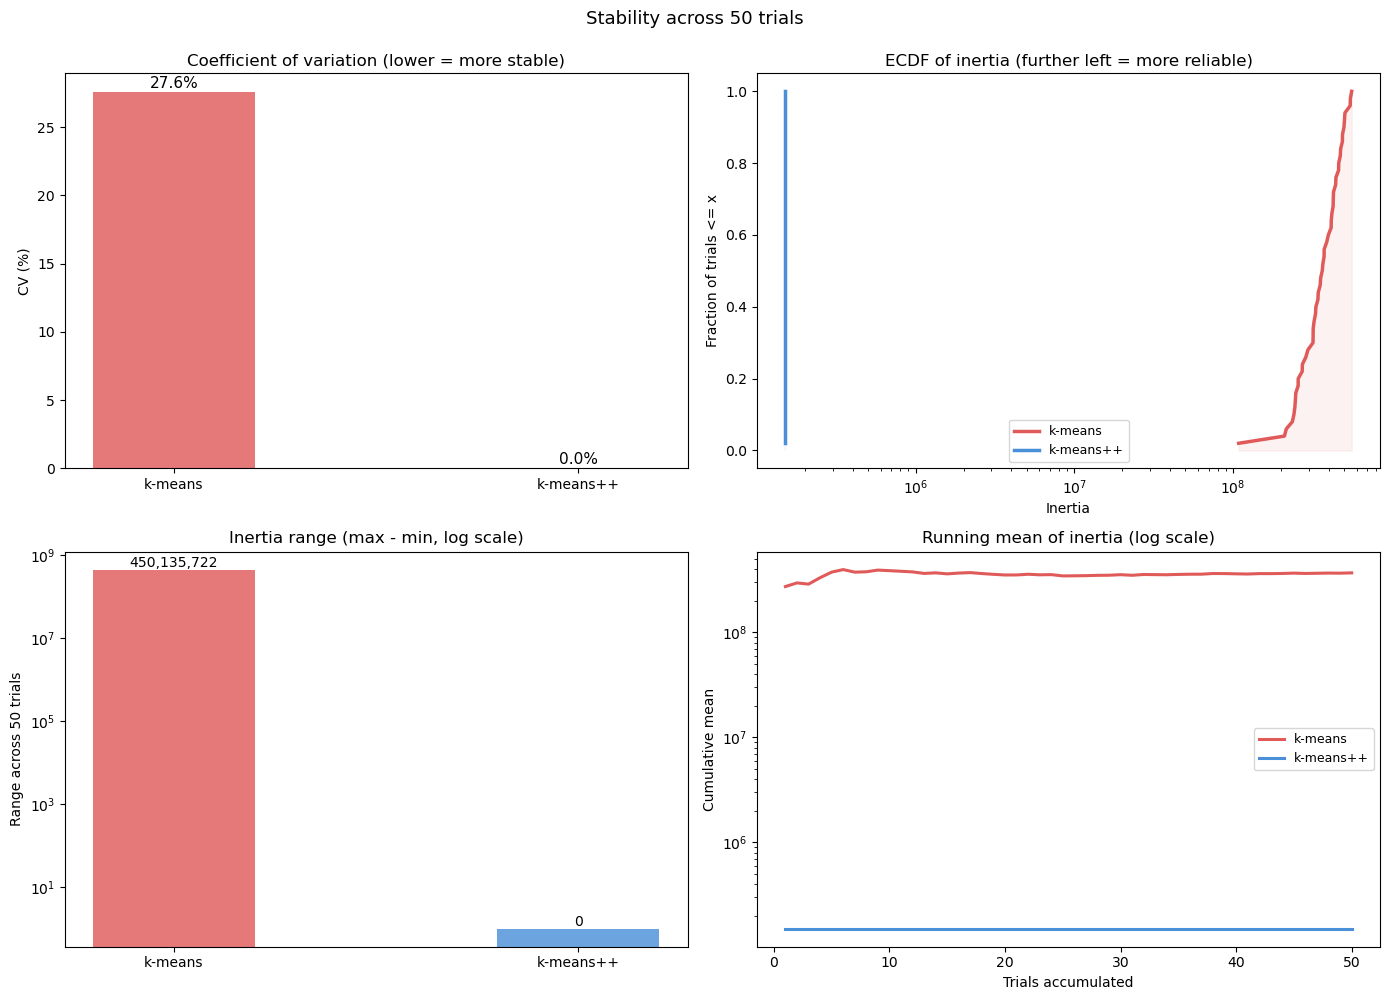

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Stability across 50 trials", fontsize=13, y=0.995)

# panel 1: coefficient of variation
ax = axes[0, 0]
cv_km = km_inertias.std() / km_inertias.mean() * 100
cv_pp = pp_inertias.std() / pp_inertias.mean() * 100
bars = ax.bar(["k-means", "k-means++"], [cv_km, cv_pp],
              color=[RED, BLUE], alpha=0.82, width=0.4)
for bar, val in zip(bars, [cv_km, cv_pp]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f"{val:.1f}%", ha="center", fontsize=11)
ax.set_title("Coefficient of variation (lower = more stable)")
ax.set_ylabel("CV (%)")

# panel 2: ECDF
ax = axes[0, 1]
for arr, color, label in [(km_inertias, RED, "k-means"),
                          (pp_inertias, BLUE, "k-means++")]:
    sorted_vals = np.sort(arr)
    cumulative = np.arange(1, len(arr) + 1) / len(arr)
    ax.plot(sorted_vals, cumulative, color=color, linewidth=2.5, label=label)
    ax.fill_between(sorted_vals, cumulative, alpha=0.08, color=color)
ax.set_xscale("log")
ax.set_title("ECDF of inertia (further left = more reliable)")
ax.set_xlabel("Inertia")
ax.set_ylabel("Fraction of trials <= x")
ax.legend(fontsize=9)

# panel 3: inertia range
ax = axes[1, 0]
range_km = km_inertias.max() - km_inertias.min()
range_pp = pp_inertias.max() - pp_inertias.min()
# guard against range_pp == 0 for log scale
plot_range_pp = max(range_pp, 1.0)
bars = ax.bar(["k-means", "k-means++"], [range_km, plot_range_pp],
              color=[RED, BLUE], alpha=0.82, width=0.4)
for bar, val in zip(bars, [range_km, range_pp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:,.0f}", ha="center", va="bottom", fontsize=10)
ax.set_yscale("log")
ax.set_title("Inertia range (max - min, log scale)")
ax.set_ylabel("Range across 50 trials")

# panel 4: running mean
ax = axes[1, 1]
running_km = np.cumsum(km_inertias) / np.arange(1, N_TRIALS + 1)
running_pp = np.cumsum(pp_inertias) / np.arange(1, N_TRIALS + 1)
ax.plot(np.arange(1, N_TRIALS + 1), running_km, color=RED, linewidth=2.2, label="k-means")
ax.plot(np.arange(1, N_TRIALS + 1), running_pp, color=BLUE, linewidth=2.2, label="k-means++")
ax.set_yscale("log")
ax.set_title("Running mean of inertia (log scale)")
ax.set_xlabel("Trials accumulated")
ax.set_ylabel("Cumulative mean")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Worst k-means vs best k-means++ (Norm25)

In [7]:
worst_km_seed = int(np.argmax(km_inertias))
best_pp_seed = int(np.argmin(pp_inertias))
worst_km_phi = km_inertias[worst_km_seed]
best_pp_phi = pp_inertias[best_pp_seed]

print(f"Worst k-means run  (trial {worst_km_seed}): inertia = {worst_km_phi:,.0f}")
print(f"Best  k-means++ run (trial {best_pp_seed}): inertia = {best_pp_phi:,.0f}")

Worst k-means run  (trial 37): inertia = 558,467,396
Best  k-means++ run (trial 0): inertia = 150,866
Ratio worst-km / best-pp: 3,702x


## A smaller dataset for visualisation

Norm25 lives in 15 dimensions, so we can't actually plot it. Here we repeat the experiment with a smaller, tamer dataset (k = 5 in 5-D), then project to 2-D with PCA so we can see what the worst k-means run and the best k-means++ run actually look like.

In [8]:
SMALL_K = 5
SMALL_N = 300
SMALL_FEATURES = 5
SMALL_STD = 1.2
SMALL_SIDE = 10
SMALL_TRIALS = 50

In [9]:
def scale(X):
    # z-score normalisation
    mu = X.mean(axis=0)
    sig = X.std(axis=0)
    return (X - mu) / sig, mu, sig


rng = np.random.default_rng(MASTER_SEED)
X_raw_s, y_true_s, _ = make_blobs(
    SMALL_N, SMALL_K, SMALL_FEATURES, SMALL_STD, SMALL_SIDE, rng
)
X_s, mu, sig = scale(X_raw_s)
print(f"X_s shape: {X_s.shape}")

X_s shape: (300, 5)


In [10]:
km_inertias_s, pp_inertias_s = run_trials(X_s, SMALL_K, n_trials=SMALL_TRIALS)

print(f"{'Metric':<10} {'k-means':>10} {'k-means++':>12}")
print("-" * 34)
for label, fn in [("Mean", np.mean), ("Std", np.std), ("Min", np.min),
                  ("Median", np.median), ("Max", np.max)]:
    print(f"{label:<10} {fn(km_inertias_s):>10.2f} {fn(pp_inertias_s):>12.2f}")

improvement_s = 100 * (1 - pp_inertias_s.mean() / km_inertias_s.mean())
print(f"\nMean improvement of k-means++ over k-means: {improvement_s:+.1f}%")

Metric        k-means    k-means++
----------------------------------
Mean           372.13       314.79
Std            113.26        88.76
Min            262.56       262.56
Median         352.71       262.56
Max            589.32       489.11

Mean improvement of k-means++ over k-means: +15.4%


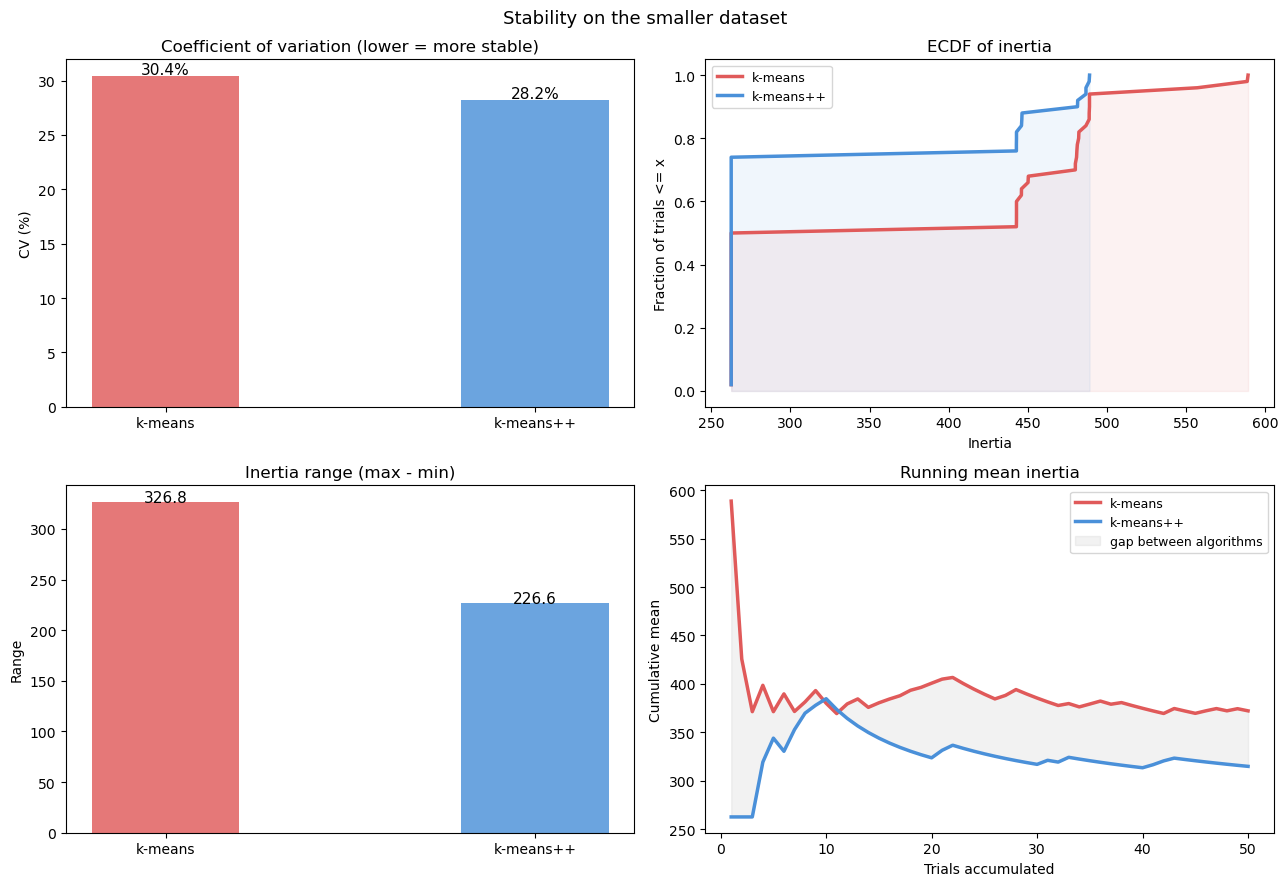

In [11]:
# stability plots for the smaller dataset
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Stability on the smaller dataset", fontsize=13)

# panel 1: CV
ax = axes[0, 0]
cv_km_s = km_inertias_s.std() / km_inertias_s.mean() * 100
cv_pp_s = pp_inertias_s.std() / pp_inertias_s.mean() * 100
bars = ax.bar(["k-means", "k-means++"], [cv_km_s, cv_pp_s],
              color=[RED, BLUE], alpha=0.82, width=0.4)
for bar, val in zip(bars, [cv_km_s, cv_pp_s]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f"{val:.1f}%", ha="center", fontsize=11)
ax.set_title("Coefficient of variation (lower = more stable)")
ax.set_ylabel("CV (%)")

# panel 2: ECDF
ax = axes[0, 1]
for arr, color, label in [(km_inertias_s, RED, "k-means"),
                          (pp_inertias_s, BLUE, "k-means++")]:
    sorted_vals = np.sort(arr)
    cumulative = np.arange(1, len(arr) + 1) / len(arr)
    ax.plot(sorted_vals, cumulative, color=color, linewidth=2.5, label=label)
    ax.fill_between(sorted_vals, cumulative, alpha=0.08, color=color)
ax.set_title("ECDF of inertia")
ax.set_xlabel("Inertia")
ax.set_ylabel("Fraction of trials <= x")
ax.legend(fontsize=9)

# panel 3: range
ax = axes[1, 0]
range_km_s = km_inertias_s.max() - km_inertias_s.min()
range_pp_s = pp_inertias_s.max() - pp_inertias_s.min()
bars = ax.bar(["k-means", "k-means++"], [range_km_s, range_pp_s],
              color=[RED, BLUE], alpha=0.82, width=0.4)
for bar, val in zip(bars, [range_km_s, range_pp_s]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"{val:.1f}", ha="center", fontsize=11)
ax.set_title("Inertia range (max - min)")
ax.set_ylabel("Range")

# panel 4: running mean
ax = axes[1, 1]
t = np.arange(1, SMALL_TRIALS + 1)
km_run_s = np.cumsum(km_inertias_s) / t
pp_run_s = np.cumsum(pp_inertias_s) / t
ax.plot(t, km_run_s, color=RED, linewidth=2.5, label="k-means")
ax.plot(t, pp_run_s, color=BLUE, linewidth=2.5, label="k-means++")
ax.fill_between(t, km_run_s, pp_run_s, alpha=0.12, color="#999",
                label="gap between algorithms")
ax.set_title("Running mean inertia")
ax.set_xlabel("Trials accumulated")
ax.set_ylabel("Cumulative mean")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

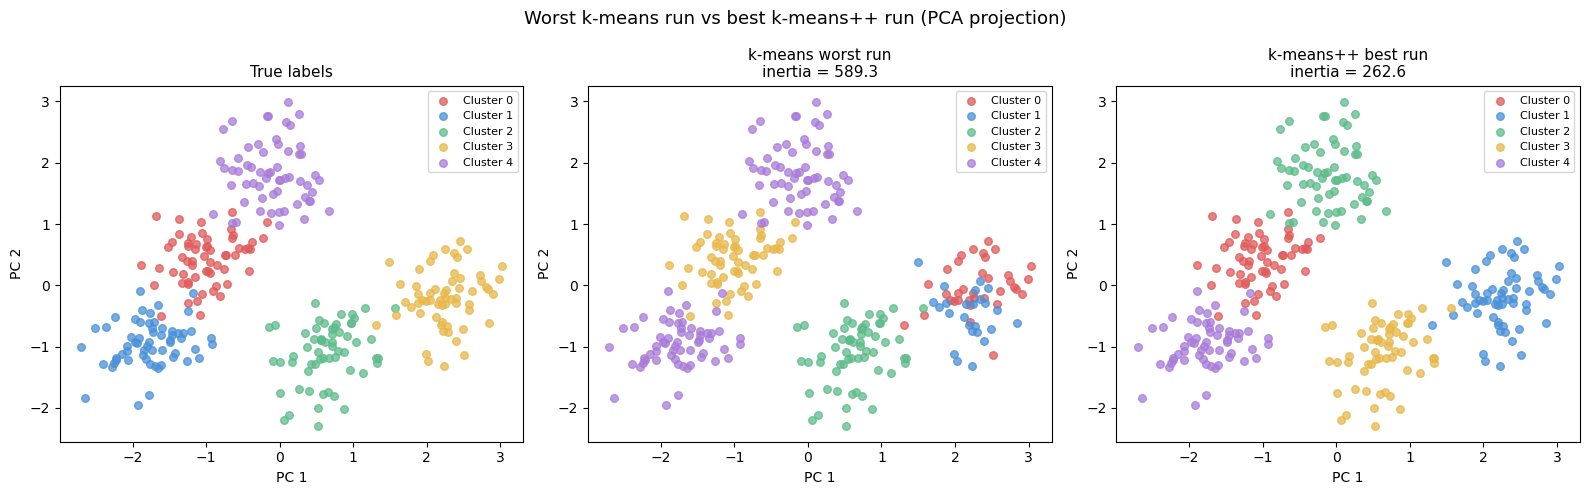

In [12]:
# pick the worst k-means trial and the best k-means++ trial on the smaller dataset
worst_km_seed_s = int(np.argmax(km_inertias_s))
best_pp_seed_s = int(np.argmin(pp_inertias_s))

# re-run those exact trials so we can recover the labels
rng = np.random.default_rng(MASTER_SEED + worst_km_seed_s)
worst_km_labels, worst_km_phi_s = kmeans(X_s, SMALL_K, rng)

rng = np.random.default_rng(MASTER_SEED + best_pp_seed_s)
best_pp_labels, best_pp_phi_s = kmeans_pp(X_s, SMALL_K, rng)


def pca_2d(X):
    X_c = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_c, full_matrices=False)
    return X_c @ Vt[:2].T


X_2d = pca_2d(X_s)

CLUSTER_COLORS = ["#E05A5A", "#4A90D9", "#5DBB8A", "#E8B84A", "#A87BD9"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Worst k-means run vs best k-means++ run (PCA projection)", fontsize=13)

panels = [
    (axes[0], y_true_s, "True labels"),
    (axes[1], worst_km_labels, f"k-means worst run\ninertia = {worst_km_phi_s:.1f}"),
    (axes[2], best_pp_labels, f"k-means++ best run\ninertia = {best_pp_phi_s:.1f}"),
]

for ax, labels, title in panels:
    for k_idx in range(SMALL_K):
        mask = labels == k_idx
        if mask.any():
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       color=CLUSTER_COLORS[k_idx],
                       s=30, alpha=0.75,
                       label=f"Cluster {k_idx}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

I declare that this material, which I now submit for assessment, is entirely my own work and has not been taken from the work of others, save and to the extent that such work has been cited and acknowledged within the text of my work. I understand that plagiarism, collusion, and copying are grave and serious offences in the university and accept the penalties that would be imposed should I engage in plagiarism, collusion or copying. This assignment, or any part of it, has not been previously submitted by me or any other person for assessment on this or any other course of study